# 04 Decision Tree Modeling

This notebook trains a Decision Tree model for the AgriCredit Resilience project.

The goal is to predict the target feature:

`financial_vulnerability`

The Decision Tree model is useful because it is explainable. It can show rules that help explain why a household is predicted as financially vulnerable or not vulnerable.

Main tasks:

1. Load the final ABT
2. Select features and target
3. Split data into training and testing sets
4. Encode categorical features
5. Train a Decision Tree Classifier
6. Evaluate model performance
7. Visualize the decision tree
8. Review feature importance
9. Save the trained model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import joblib

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

ABT_PATH = PROCESSED_DATA_DIR / "farmer_vulnerability_abt.csv"

ABT_PATH

PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/data/processed/farmer_vulnerability_abt.csv')

In [3]:
abt = pd.read_csv(ABT_PATH)

abt.head()

,household_id,state_region,township,household_size,female_headed_household,disability_present,displacement_status,monthly_income,has_debt,total_debt,...,cash_food_assistance_per_person,household_meb_requirement,income_to_meb_ratio,meb_gap,coverage_rate,coverage_gap_ratio,response_gap,number_of_partners_active,vulnerability_score,financial_vulnerability
0,HH00001,Magway,Magway,6,0,0,IDP,610149.0,1,851624,...,30000,330000,1.848936,280149.0,0.380,0.620,15359,21,3,1
1,HH00002,Ayeyarwady,Pathein,8,0,0,Resident,284061.0,1,801819,...,35000,440000,0.645593,-155939.0,0.424,0.576,56238,21,4,1
2,HH00003,Shan North,Lashio,4,0,0,Resident,50000.0,0,0,...,50000,240000,0.208333,-190000.0,0.607,0.393,9415,17,5,1
3,HH00004,Kayin,Hpa-An,4,0,0,Resident,101947.0,1,667989,...,40000,260000,0.392104,-158053.0,0.387,0.613,128076,20,3,1
4,HH00005,Kayin,Myawaddy,6,0,0,Returnee,675893.0,1,593253,...,40000,390000,1.733059,285893.0,0.387,0.613,128076,20,3,1


In [4]:
print(f"Rows: {abt.shape[0]}")
print(f"Columns: {abt.shape[1]}")

abt["financial_vulnerability"].value_counts().sort_index()

Rows: 1500
Columns: 44


financial_vulnerability
0    555
1    945
Name: count, dtype: int64

## Dataset Check

The final ABT contains one row per household. The target feature is `financial_vulnerability`.

The target has two classes:

- `0` = not financially vulnerable
- `1` = financially vulnerable

The dataset is slightly imbalanced because there are more vulnerable households than non-vulnerable households. Because of this, evaluation should not rely only on accuracy. Precision, recall, F1-score, and the confusion matrix should also be used.

In [5]:
target_column = "financial_vulnerability"

y = abt[target_column]

y.head()

0    1
1    1
2    1
3    1
4    1
Name: financial_vulnerability, dtype: int64

In [6]:
feature_columns = [
    # Location/context
    "state_region",

    # Household characteristics
    "household_size",
    "female_headed_household",
    "disability_present",
    "displacement_status",

    # Financial features
    "monthly_income",
    "has_debt",
    "total_debt",
    "monthly_debt_repayment",
    "savings_duration_weeks",
    "debt_to_income_ratio",
    "monthly_debt_repayment_ratio",

    # Market access
    "market_access",

    # Agriculture features
    "is_farming_household",
    "main_crop",
    "farm_size_acres",
    "irrigation_access",
    "fertilizer_cost",
    "crop_damage_recent",

    # Coping and basic needs
    "rCSI_score",
    "basic_needs_score",

    # Market context
    "basic_food_basket_change_1y",
    "rice_price_change_1y",
    "fuel_price_change_1y",
    "market_disruption_score",
    "market_pressure_score",

    # MEB features
    "mpca_per_person",
    "household_meb_requirement",
    "income_to_meb_ratio",
    "meb_gap",

    # Assistance coverage
    "coverage_rate",
    "coverage_gap_ratio",
    "response_gap",
    "number_of_partners_active",
]

X = abt[feature_columns].copy()

X.head()

,state_region,household_size,female_headed_household,disability_present,displacement_status,monthly_income,has_debt,total_debt,monthly_debt_repayment,savings_duration_weeks,...,market_disruption_score,market_pressure_score,mpca_per_person,household_meb_requirement,income_to_meb_ratio,meb_gap,coverage_rate,coverage_gap_ratio,response_gap,number_of_partners_active
0,Magway,6,0,0,IDP,610149.0,1,851624,150329,1,...,1,91.4,55000,330000,1.848936,280149.0,0.380,0.620,15359,21
1,Ayeyarwady,8,0,0,Resident,284061.0,1,801819,95454,4,...,1,70.9,55000,440000,0.645593,-155939.0,0.424,0.576,56238,21
2,Shan North,4,0,0,Resident,50000.0,0,0,0,2,...,2,78.5,60000,240000,0.208333,-190000.0,0.607,0.393,9415,17
3,Kayin,4,0,0,Resident,101947.0,1,667989,60245,2,...,1,66.5,65000,260000,0.392104,-158053.0,0.387,0.613,128076,20
4,Kayin,6,0,0,Returnee,675893.0,1,593253,81094,1,...,1,66.5,65000,390000,1.733059,285893.0,0.387,0.613,128076,20


In [7]:
X.dtypes

state_region                        str
household_size                    int64
female_headed_household           int64
disability_present                int64
displacement_status                 str
monthly_income                  float64
has_debt                          int64
total_debt                        int64
monthly_debt_repayment            int64
savings_duration_weeks            int64
debt_to_income_ratio            float64
monthly_debt_repayment_ratio    float64
market_access                   float64
is_farming_household              int64
main_crop                           str
farm_size_acres                 float64
irrigation_access                 int64
fertilizer_cost                 float64
crop_damage_recent                int64
rCSI_score                      float64
basic_needs_score                 int64
basic_food_basket_change_1y     float64
rice_price_change_1y            float64
fuel_price_change_1y            float64
market_disruption_score           int64


In [8]:
categorical_features = [
    "state_region",
    "displacement_status",
    "main_crop",
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of numeric features:")
print(len(numeric_features))

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['state_region', 'displacement_status', 'main_crop']

Number of numeric features:
31

Numeric features:
['household_size', 'female_headed_household', 'disability_present', 'monthly_income', 'has_debt', 'total_debt', 'monthly_debt_repayment', 'savings_duration_weeks', 'debt_to_income_ratio', 'monthly_debt_repayment_ratio', 'market_access', 'is_farming_household', 'farm_size_acres', 'irrigation_access', 'fertilizer_cost', 'crop_damage_recent', 'rCSI_score', 'basic_needs_score', 'basic_food_basket_change_1y', 'rice_price_change_1y', 'fuel_price_change_1y', 'market_disruption_score', 'market_pressure_score', 'mpca_per_person', 'household_meb_requirement', 'income_to_meb_ratio', 'meb_gap', 'coverage_rate', 'coverage_gap_ratio', 'response_gap', 'number_of_partners_active']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training rows: 1200
Testing rows: 300

Training target distribution:
financial_vulnerability
0    0.37
1    0.63
Name: proportion, dtype: float64

Testing target distribution:
financial_vulnerability
0    0.37
1    0.63
Name: proportion, dtype: float64


## Train/Test Split

The dataset was split into training and testing sets. The training set is used to train the Decision Tree model, while the testing set is used to evaluate how well the model performs on unseen data.

A stratified split was used so that the target distribution remains similar in both the training and testing sets.

## Build Decision Tree Pipeline

The Decision Tree model needs numeric input. Most features are already numeric, but some features are categorical text values.

Categorical features:

- `state_region`
- `displacement_status`
- `main_crop`

These categorical features will be converted into numeric columns using one-hot encoding.

The Decision Tree model will be limited using `max_depth` and `min_samples_leaf` so that the tree remains readable and does not overfit too much.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    random_state=42,
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model),
    ]
)

decision_tree_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

In [11]:
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [12]:
y_pred = decision_tree_pipeline.predict(X_test)

y_pred[:10]

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 0])

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_metrics = {
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4),
}

model_metrics

{'accuracy': 0.8067, 'precision': 0.8503, 'recall': 0.8413, 'f1_score': 0.8457}

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74       111
           1       0.85      0.84      0.85       189

    accuracy                           0.81       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.81      0.81      0.81       300



### Observation

The Decision Tree model achieved about 81% accuracy on the test set. For the financially vulnerable class, the model achieved strong precision and recall. This means the model is reasonably good at identifying vulnerable households.

The model performs slightly better on class `1` than class `0`, partly because the dataset contains more financially vulnerable households. Since this project focuses on identifying vulnerable households, recall and F1-score are especially important, not only accuracy.

In [15]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[ 83,  28],
       [ 30, 159]])

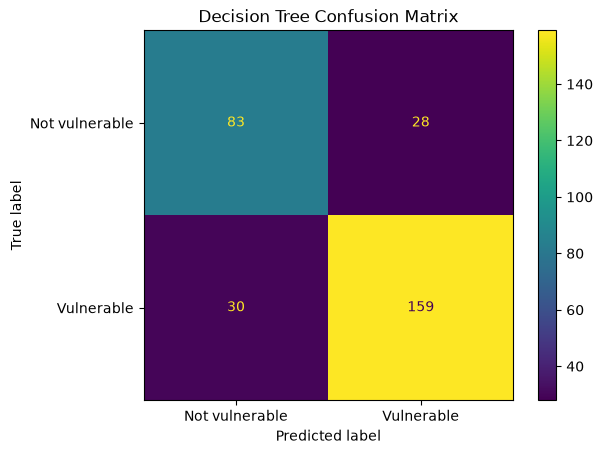

In [16]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not vulnerable", "Vulnerable"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Confusion Matrix Explanation

The confusion matrix shows how many test records were correctly and incorrectly classified.

- True Negative: not vulnerable households correctly predicted as not vulnerable
- False Positive: not vulnerable households incorrectly predicted as vulnerable
- False Negative: vulnerable households incorrectly predicted as not vulnerable
- True Positive: vulnerable households correctly predicted as vulnerable

For this project, false negatives are especially important because they represent vulnerable households that the model failed to identify.

### Observation

The confusion matrix shows that the Decision Tree correctly predicted 83 not vulnerable households and 159 vulnerable households.

The model made 28 false positive errors, meaning some not vulnerable households were predicted as vulnerable. It also made 30 false negative errors, meaning some vulnerable households were missed.

For this project, false negatives are especially important because they represent vulnerable households that the model failed to identify. The model correctly identified 159 out of 189 vulnerable households, giving a vulnerable-class recall of about 84%.

## Visualize the Decision Tree

A Decision Tree can be interpreted as a set of if-then rules. Each split in the tree checks one feature and separates households into groups.

Visualizing the tree helps explain how the model predicts whether a household is financially vulnerable.

In [17]:
# Get feature names after one-hot encoding
encoded_feature_names = decision_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()

encoded_feature_names[:20]

array(['categorical__state_region_Ayeyarwady',
       'categorical__state_region_Bago', 'categorical__state_region_Chin',
       'categorical__state_region_Kachin',
       'categorical__state_region_Kayah',
       'categorical__state_region_Kayin',
       'categorical__state_region_Magway',
       'categorical__state_region_Mandalay',
       'categorical__state_region_Mon',
       'categorical__state_region_Rakhine',
       'categorical__state_region_Sagaing',
       'categorical__state_region_Shan North',
       'categorical__state_region_Shan South',
       'categorical__state_region_Tanintharyi',
       'categorical__displacement_status_IDP',
       'categorical__displacement_status_Resident',
       'categorical__displacement_status_Returnee',
       'categorical__main_crop_Maize', 'categorical__main_crop_Mixed',
       'categorical__main_crop_Oilseed'], dtype=object)

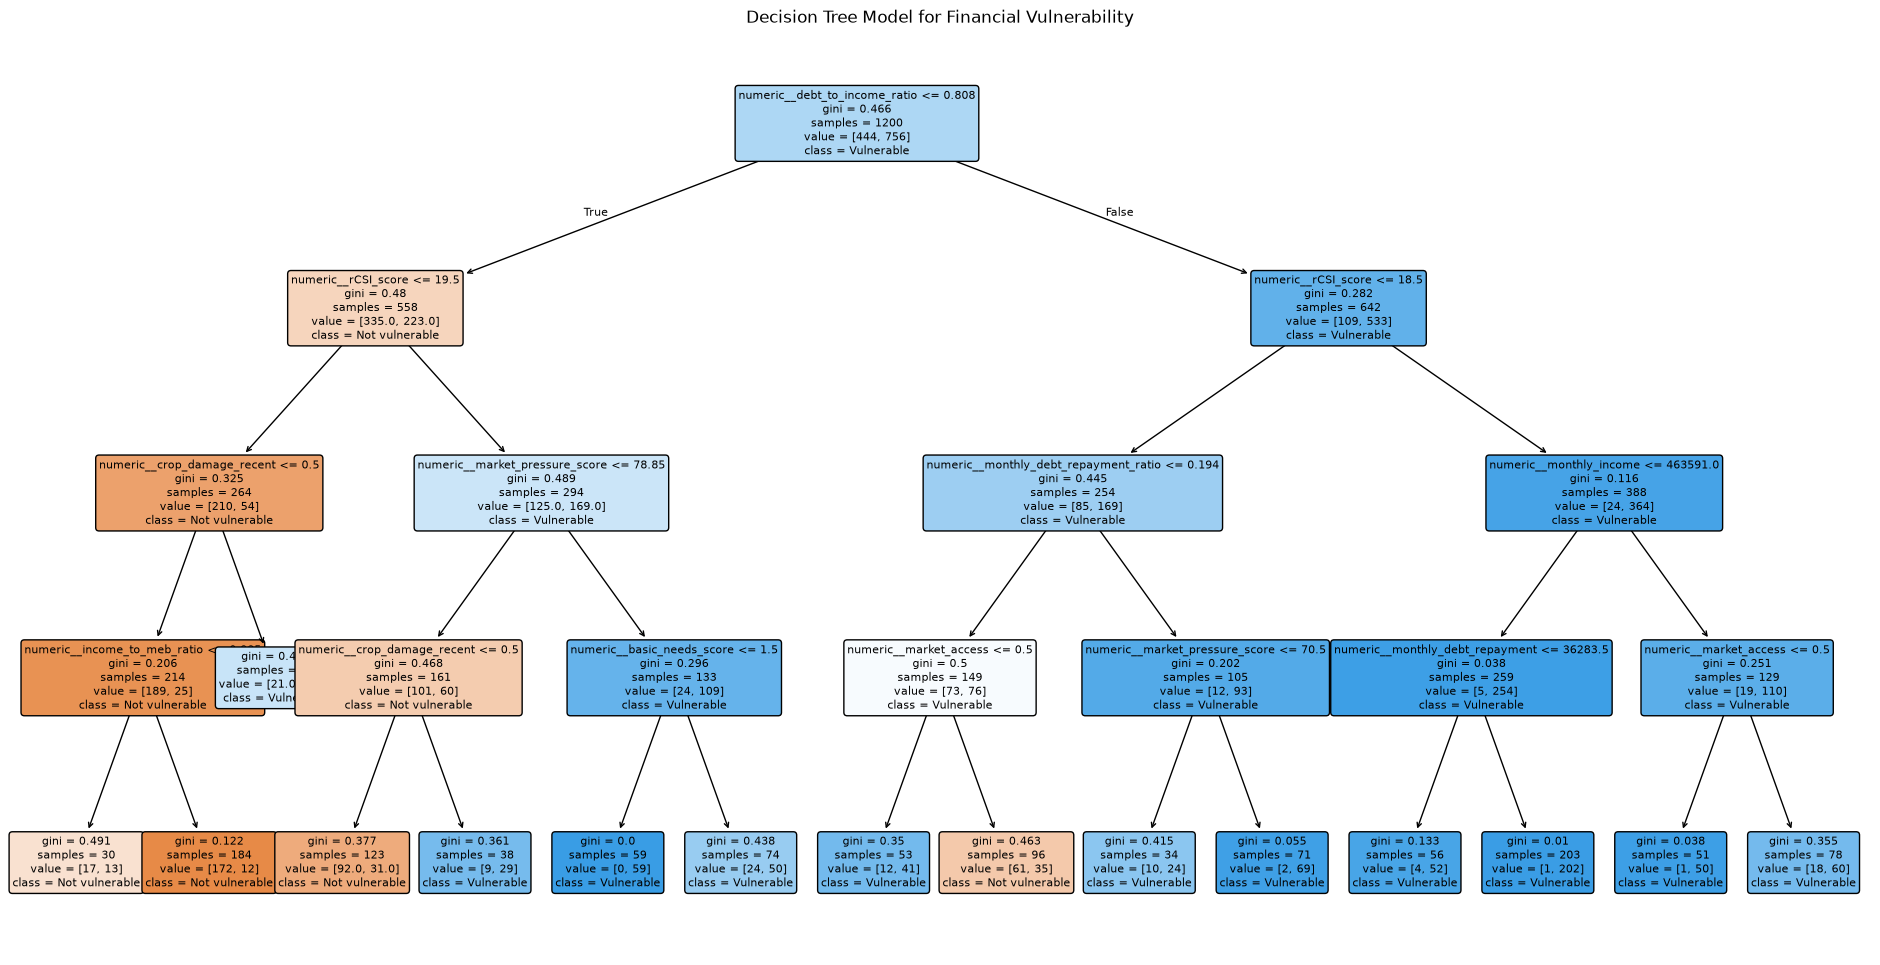

In [18]:
tree_model = decision_tree_pipeline.named_steps["model"]

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=encoded_feature_names,
    class_names=["Not vulnerable", "Vulnerable"],
    filled=True,
    rounded=True,
    fontsize=8,
)

plt.title("Decision Tree Model for Financial Vulnerability")
plt.show()

### Observation

The Decision Tree visualization shows the main rules used by the model. Each internal node represents a decision based on a feature value, and each leaf node gives a final prediction.

Because the tree was limited with `max_depth=4`, it remains easier to interpret than a very deep tree. This supports the goal of using Decision Trees as an explainable model for household financial vulnerability.

In [19]:
from sklearn.tree import export_text

In [20]:
tree_rules = export_text(
    tree_model,
    feature_names=list(encoded_feature_names),
    max_depth=4,
)

print(tree_rules)

|--- numeric__debt_to_income_ratio <= 0.81
|   |--- numeric__rCSI_score <= 19.50
|   |   |--- numeric__crop_damage_recent <= 0.50
|   |   |   |--- numeric__income_to_meb_ratio <= 0.94
|   |   |   |   |--- class: 0
|   |   |   |--- numeric__income_to_meb_ratio >  0.94
|   |   |   |   |--- class: 0
|   |   |--- numeric__crop_damage_recent >  0.50
|   |   |   |--- class: 1
|   |--- numeric__rCSI_score >  19.50
|   |   |--- numeric__market_pressure_score <= 78.85
|   |   |   |--- numeric__crop_damage_recent <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- numeric__crop_damage_recent >  0.50
|   |   |   |   |--- class: 1
|   |   |--- numeric__market_pressure_score >  78.85
|   |   |   |--- numeric__basic_needs_score <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- numeric__basic_needs_score >  1.50
|   |   |   |   |--- class: 1
|--- numeric__debt_to_income_ratio >  0.81
|   |--- numeric__rCSI_score <= 18.50
|   |   |--- numeric__monthly_debt_repayment_ratio <= 0.19
|   |   |   |

### Rule Interpretation

The printed tree rules show the same logic as the visual tree, but in text form. These rules help explain how the model separates vulnerable and not vulnerable households.

For example, the model may use features such as income relative to MEB, coping strategy score, basic needs score, debt pressure, market access, or crop damage to make predictions.

This is useful for the project because the goal is not only to predict vulnerability, but also to explain why a household may be considered vulnerable.

### Decision Tree Rule Observation

The Decision Tree uses `debt_to_income_ratio` as the first split, meaning debt pressure is the most important initial factor in the model. After that, the model uses features such as `rCSI_score`, `crop_damage_recent`, `market_pressure_score`, `basic_needs_score`, `monthly_debt_repayment_ratio`, `market_access`, and `monthly_income`.

The rules are understandable and align with the project goal. Households with higher debt pressure, higher coping strategy scores, poor market access, crop damage, and higher market pressure are more likely to be predicted as financially vulnerable.

This supports the use of a Decision Tree as an explainable model because the prediction can be explained through clear if-then rules.

## Feature Importance

Feature importance shows which variables the Decision Tree relied on most when predicting financial vulnerability.

This is useful because the model should not only make predictions, but also help explain which factors are most related to household vulnerability.

In [21]:
feature_importance = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": tree_model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
32,numeric__debt_to_income_ratio,0.388059
40,numeric__rCSI_score,0.213814
39,numeric__crop_damage_recent,0.114143
46,numeric__market_pressure_score,0.113382
33,numeric__monthly_debt_repayment_ratio,0.060941
34,numeric__market_access,0.049692
49,numeric__income_to_meb_ratio,0.024508
41,numeric__basic_needs_score,0.024210
27,numeric__monthly_income,0.009889
30,numeric__monthly_debt_repayment,0.001361


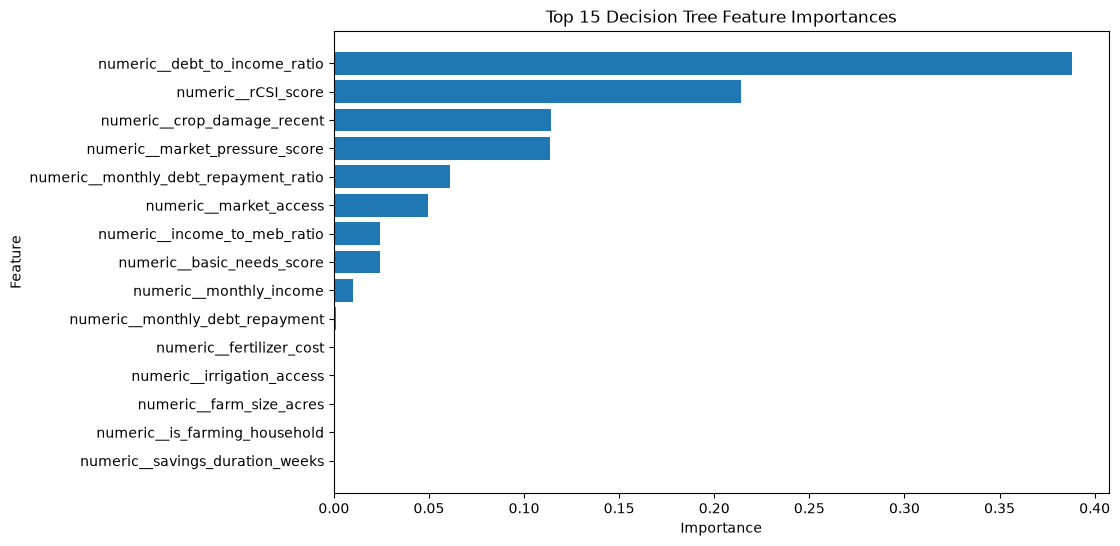

In [22]:
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 15 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [23]:
feature_importance_clean = feature_importance.copy()

feature_importance_clean["feature_clean"] = (
    feature_importance_clean["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance_clean[[
    "feature_clean",
    "importance"
]].head(15)

,feature_clean,importance
32,debt_to_income_ratio,0.388059
40,rCSI_score,0.213814
39,crop_damage_recent,0.114143
46,market_pressure_score,0.113382
33,monthly_debt_repayment_ratio,0.060941
34,market_access,0.049692
49,income_to_meb_ratio,0.024508
41,basic_needs_score,0.024210
27,monthly_income,0.009889
30,monthly_debt_repayment,0.001361


### Feature Importance Observation

The Decision Tree feature importance results show which variables were most useful for predicting financial vulnerability.

The most important features are expected to include debt pressure, coping strategy score, market access, market pressure, basic needs score, income, and MEB-related features. These features align with the project logic because household vulnerability is connected to income, debt, food coping behavior, market conditions, and access to basic needs.

Feature importance supports the explainability of the Decision Tree model because it shows which factors the model relied on most.

### Feature Importance Observation

The Decision Tree feature importance results show that `debt_to_income_ratio` is the most important feature in the model. This means debt pressure is the strongest factor used by the tree when predicting financial vulnerability.

Other important features include `rCSI_score`, `crop_damage_recent`, `market_pressure_score`, `monthly_debt_repayment_ratio`, `market_access`, `income_to_meb_ratio`, and `basic_needs_score`.

These results align with the project logic. Financial vulnerability is strongly connected to debt burden, food coping behavior, crop damage, market pressure, market access, and income compared with minimum expenditure needs.

Some features have zero importance because this limited-depth tree did not use them for splitting. This does not mean they are always useless; it only means they were not selected by this specific Decision Tree model.

In [24]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "decision_tree_model.joblib"

joblib.dump(decision_tree_pipeline, model_path)

model_path

PosixPath('/Users/isaacaung/Desktop/agricredit-resilience/models/decision_tree_model.joblib')

In [25]:
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(X_test)

print("Loaded model accuracy:", round(accuracy_score(y_test, loaded_predictions), 4))

Loaded model accuracy: 0.8067


## Decision Tree Modeling Summary

The Decision Tree model was trained successfully to predict `financial_vulnerability`.

The model achieved about 81% accuracy on the test set. For the vulnerable class, the model achieved strong precision and recall, meaning it was reasonably effective at identifying financially vulnerable households.

The confusion matrix showed that the model correctly identified 159 vulnerable households and missed 30 vulnerable households. Because this project focuses on vulnerability detection, false negatives are especially important.

The Decision Tree visualization and printed rules showed that the model mainly used debt pressure, coping strategy score, crop damage, market pressure, market access, income, and basic needs coverage. This makes the model explainable and suitable for a decision-support project.

The trained Decision Tree pipeline was saved to:

`models/decision_tree_model.joblib`